# Simuating a Markov Chain
The Markov Propery states that 
$$P(s_{t+1} | s_t, s_{t-1}, ..., s_0) = P(s_{t+1} | s_t)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)

In [13]:
# Transition matrix T[i,j] = P(next=j | current=i)
T = np.array([
    [0.6, 0.2, 0.1, 0.1],  # from Sunny
    [0.3, 0.3, 0.3, 0.1],  # from Cloudy
    [0.1, 0.3, 0.4, 0.2],  # from Rainy
    [0.1, 0.1, 0.4, 0.4],  # from Stormy
])

state_names = ['Sunny', 'Cloudy', 'Rainy', 'Stormy']

# Verify rows sum to 1
assert np.allclose(T.sum(axis=1), 1), "Rows must sum to 1!"
print("Transition matrix:")
print(T)

Transition matrix:
[[0.6 0.2 0.1 0.1]
 [0.3 0.3 0.3 0.1]
 [0.1 0.3 0.4 0.2]
 [0.1 0.1 0.4 0.4]]


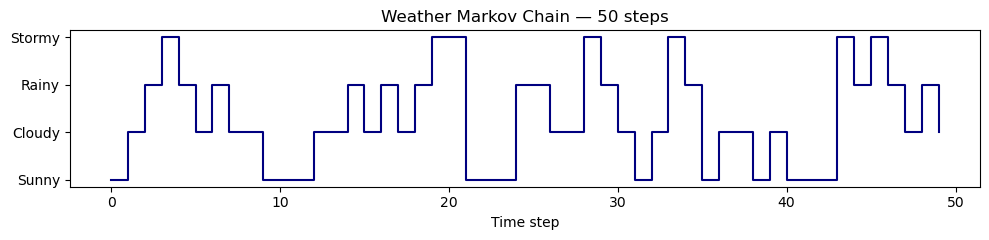

In [14]:
def simulate_markov(T, start_state, n_steps):
    trajectory = [start_state]
    state = start_state
    for _ in range(n_steps - 1):
        state = np.random.choice(len(T), p=T[state])
        trajectory.append(state)
    return np.array(trajectory)

traj = simulate_markov(T, start_state=0, n_steps=50)

plt.figure(figsize=(10, 2.5))
colors = ['gold', 'skyblue', 'steelblue', 'maroon']
plt.step(range(len(traj)), traj, where='post', color='navy', linewidth=1.5)
plt.yticks([0,1,2,3], state_names)
plt.xlabel('Time step'); plt.title('Weather Markov Chain — 50 steps')
plt.tight_layout(); plt.show()

In [15]:
# Analytical: left eigenvector
eigenvalues, eigenvectors = np.linalg.eig(T.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))  # eigenvalue closest to 1
stationary_analytical = np.real(eigenvectors[:, idx])
stationary_analytical /= stationary_analytical.sum()
print("Analytical stationary distribution:", np.round(stationary_analytical, 4))

# Empirical: simulate 100,000 steps
long_traj = simulate_markov(T, start_state=0, n_steps=100_000)
stationary_empirical = np.bincount(long_traj) / len(long_traj)
print("Empirical  stationary distribution:", np.round(stationary_empirical, 4))

Analytical stationary distribution: [0.2935 0.2338 0.2886 0.1841]
Empirical  stationary distribution: [0.2976 0.236  0.2856 0.1808]


# Verifying Convergence
The chain should converge to the stationary distribution.

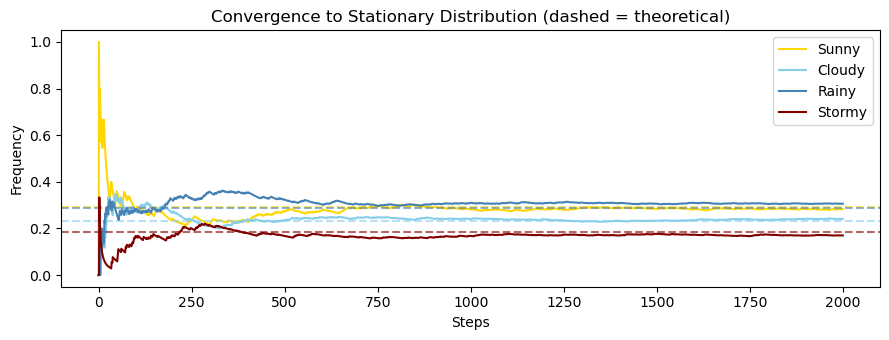

In [17]:
# Visualise convergence to stationary distribution
n_steps = 2000
state_freq = np.zeros((n_steps, 4))
traj_long = simulate_markov(T, start_state=0, n_steps=n_steps)
for t in range(1, n_steps):
    state_freq[t] = np.bincount(traj_long[:t+1], minlength=4) / (t+1)

fig, ax = plt.subplots(figsize=(9, 3.5))
colors_ = ['gold', 'skyblue', 'steelblue', 'maroon']
for i, (name, c) in enumerate(zip(state_names, colors_)):
    ax.plot(state_freq[:, i], color=c, linewidth=1.5, label=name)
    ax.axhline(stationary_analytical[i], color=c, linestyle='--', alpha=0.6)
ax.set_xlabel('Steps'); ax.set_ylabel('Frequency')
ax.set_title('Convergence to Stationary Distribution (dashed = theoretical)')
ax.legend(); plt.tight_layout(); plt.show()

In [18]:
init = np.array([1.0, 0.0, 0.0, 0.0])  # start in Sunny
print(f"t=0:  {init}")
Tn = T.copy()
for t in [1, 5, 10, 50]:
    Tn_power = np.linalg.matrix_power(T, t)
    dist = init @ Tn_power
    print(f"t={t:<4}: {np.round(dist, 4)}")  # should converge to stationary

t=0:  [1. 0. 0. 0.]
t=1   : [0.6 0.2 0.1 0.1]
t=5   : [0.31   0.2326 0.2786 0.1788]
t=10  : [0.294  0.2338 0.2883 0.1839]
t=50  : [0.2935 0.2338 0.2886 0.1841]


# Always rains condition
The condition that if it rains, it always rains. (absorbing state)
The rainy row now becomes [0, 0, 1].

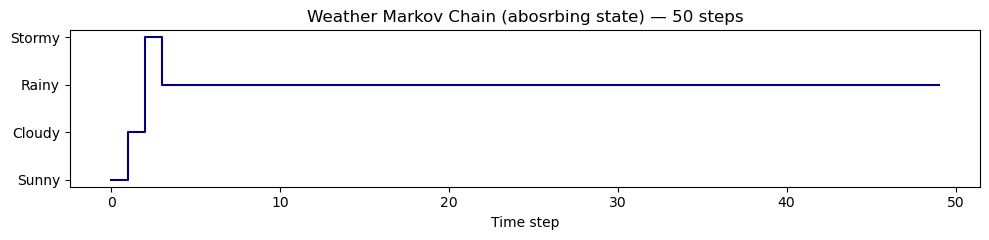

In [24]:
T_new = np.array([
    [0.6, 0.2, 0.1, 0.1],  
    [0.3, 0.3, 0.3, 0.1],  
    [0.0, 0.0, 1.0, 0.0],  # stays Rainy
    [0.1, 0.1, 0.4, 0.4],  
])

traj_new = simulate_markov(T_new, start_state=0, n_steps=50)

plt.figure(figsize=(10, 2.5))
plt.step(range(len(traj_new)), traj_new, where='post', color='navy', linewidth=1.5)
plt.yticks([0,1,2,3], state_names)
plt.xlabel('Time step'); plt.title('Weather Markov Chain (abosrbing state) — 50 steps')
plt.tight_layout(); plt.show()

In [26]:
eigenvalues_new, eigenvectors_new = np.linalg.eig(T_new.T)
idx_new = np.argmin(np.abs(eigenvalues_new - 1.0))  # eigenvalue closest to 1
stationary_analytical_new = np.real(eigenvectors_new[:, idx_new])
stationary_analytical_new /= stationary_analytical_new.sum()
print("Analytical stationary distribution:", np.round(stationary_analytical_new, 4))

# Empirical: simulate 100,000 steps
long_traj_new = simulate_markov(T_new, start_state=0, n_steps=100_000)
stationary_empirical_new = np.bincount(long_traj_new) / len(long_traj_new)
print("Empirical  stationary distribution:", np.round(stationary_empirical_new, 4))

Analytical stationary distribution: [0. 0. 1. 0.]
Empirical  stationary distribution: [0. 0. 1. 0.]


## Stationary Distribution
The stationary distribution will be [0.0, 0.0, 1.0, 0.0]. The state will always remain at rainy. The chain converges to [0.0, 0.0, 1.0, 0.0].

# Proving π @ T == π

In [28]:
pi = np.real(eigenvectors[:, idx])
pi /= pi.sum()

print("π:      ", np.round(pi, 6))
print("π @ T:  ", np.round(pi @ T, 6))

# The assertion
assert np.allclose(pi @ T, pi, atol=1e-6), "Stationary distribution check failed!"
print("Assertion passed:  π @ T == π confirmed.")

π:       [0.293532 0.233831 0.288557 0.18408 ]
π @ T:   [0.293532 0.233831 0.288557 0.18408 ]
Assertion passed:  π @ T == π confirmed.


This asserts us that the given condition is true for our stationary distribution.